In [213]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/CypranA/Data-Visualization-With-Seaborn/main/young-people-survey-responses.csv')

## Part 1: Data Loading and Initial Exploration

(1010, 16)
   Unnamed: 0  Music  Techno  Movies  History  Mathematics  Pets  Spiders  \
0           0    5.0     1.0     5.0      1.0          3.0   4.0      1.0   
1           1    4.0     1.0     5.0      1.0          5.0   5.0      1.0   
2           2    5.0     1.0     5.0      1.0          5.0   5.0      1.0   
3           3    5.0     2.0     5.0      4.0          4.0   1.0      5.0   
4           4    5.0     2.0     5.0      3.0          2.0   1.0      1.0   

   Loneliness  Parents' advice   Internet usage  Finances   Age  Siblings  \
0         3.0              4.0  few hours a day       3.0  20.0       1.0   
1         2.0              2.0  few hours a day       3.0  19.0       2.0   
2         5.0              3.0  few hours a day       2.0  20.0       2.0   
3         5.0              2.0  most of the day       2.0  22.0       1.0   
4         3.0              3.0  few hours a day       4.0  20.0       1.0   

   Gender Village - town  
0  female        village  
1  female

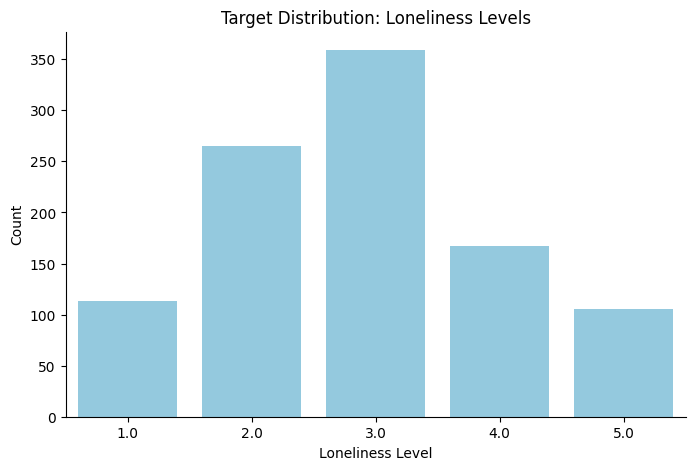

In [214]:
# 1. Dataset Overview
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

# 2. Initial Data Quality
# Table of null value counts
print(df.isnull().sum())

# Value counts for important categorical variables
print("\n--- Village - town value counts ---")
print(df["Village - town"].value_counts())

print("\n--- Internet usage value counts ---")
print(df["Internet usage"].value_counts())

# Target Distribution (Loneliness)
plt.figure(figsize=(8, 5))
sns.countplot(x='Loneliness', data=df, color='skyblue')
plt.title('Target Distribution: Loneliness Levels', fontsize=12)
plt.xlabel('Loneliness Level', fontsize=10)
plt.ylabel('Count', fontsize=10)
sns.despine()

## Part 2: Exploratory Data Analysis (EDA)

In [215]:
df = df.drop(columns=['Unnamed: 0'])
numeric = ['Movies', 'History', 'Mathematics', 'Pets', 'Spiders', 'Loneliness',
           'Finances', 'Age', 'Music', "Parents' advice", 'Techno', 'Siblings']
categorical = ['Internet usage', 'Gender', 'Village - town']

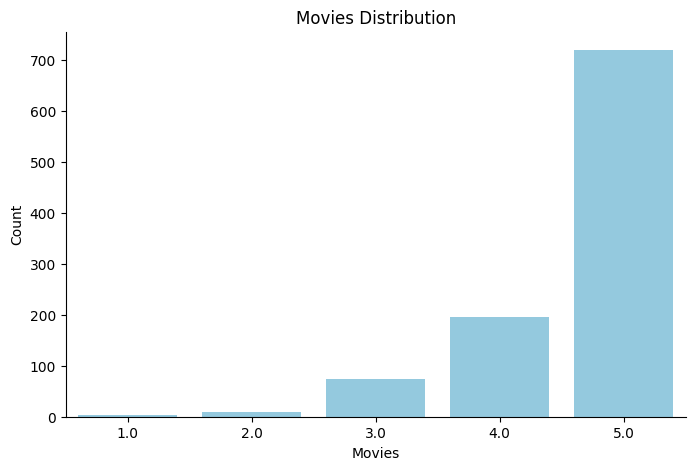

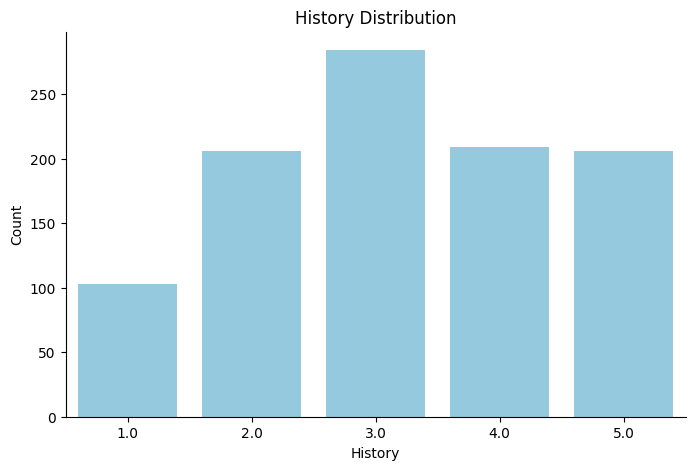

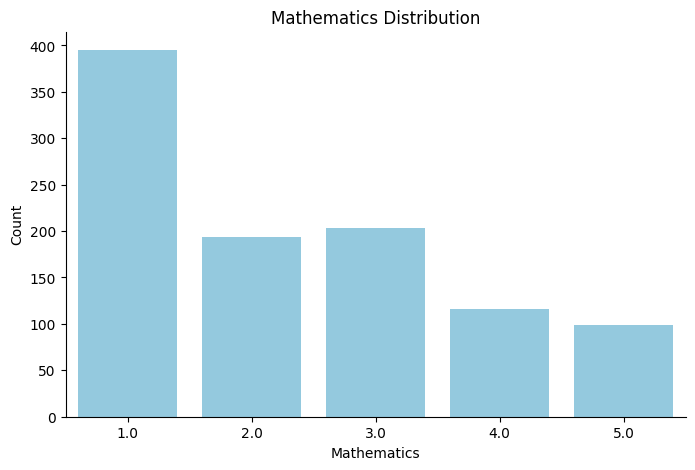

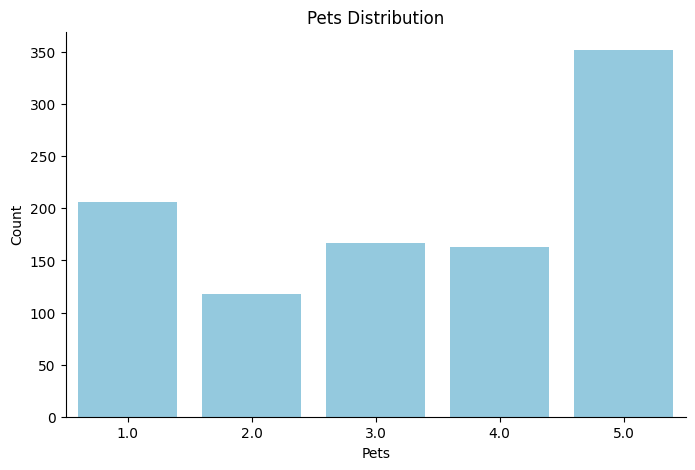

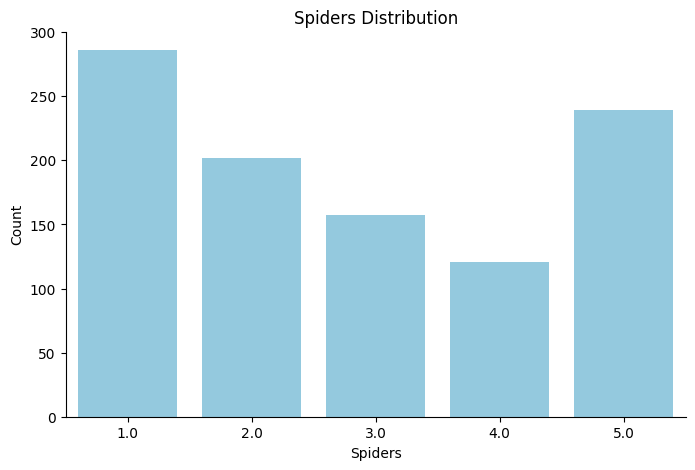

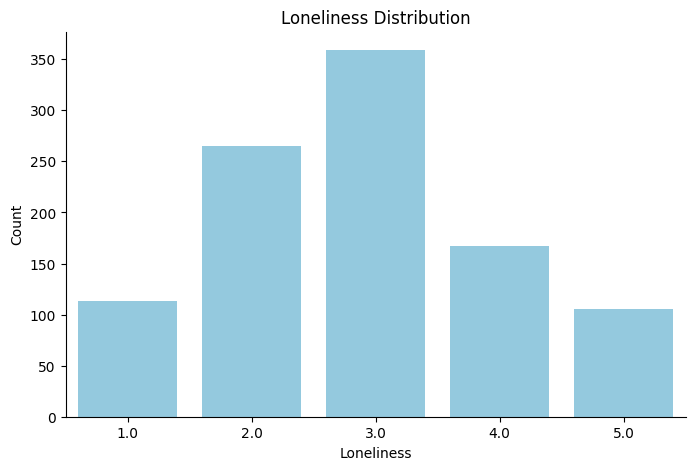

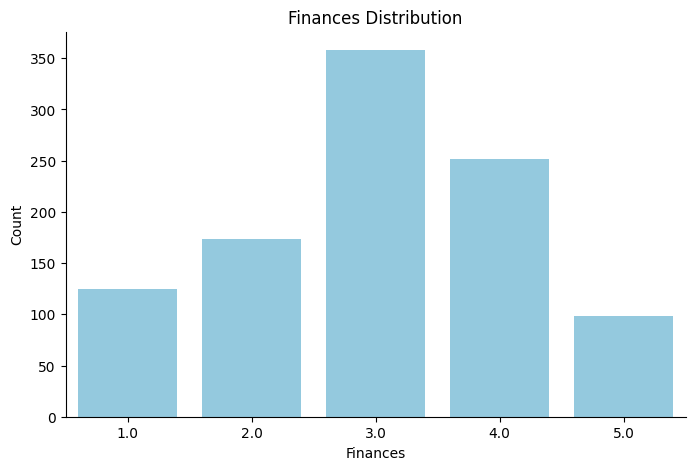

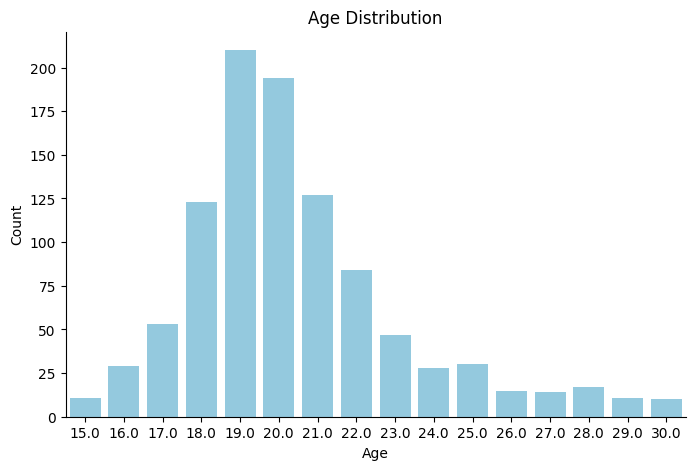

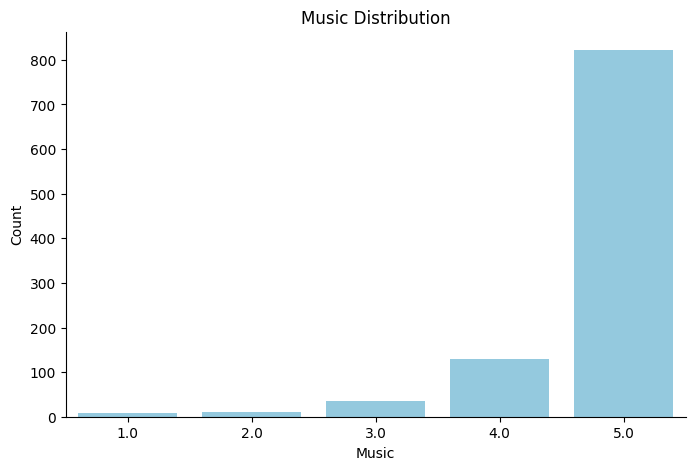

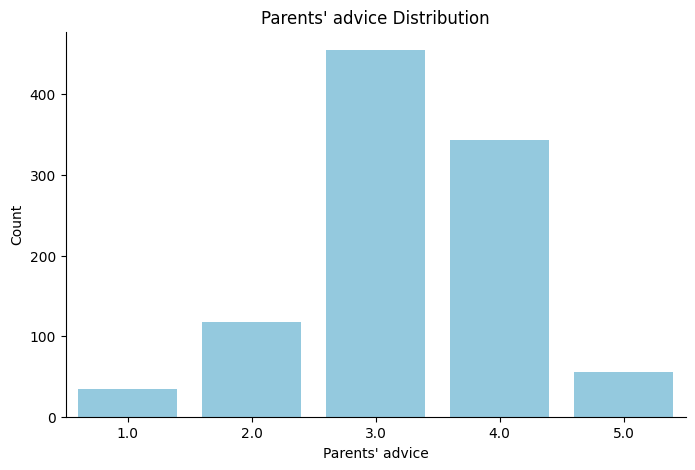

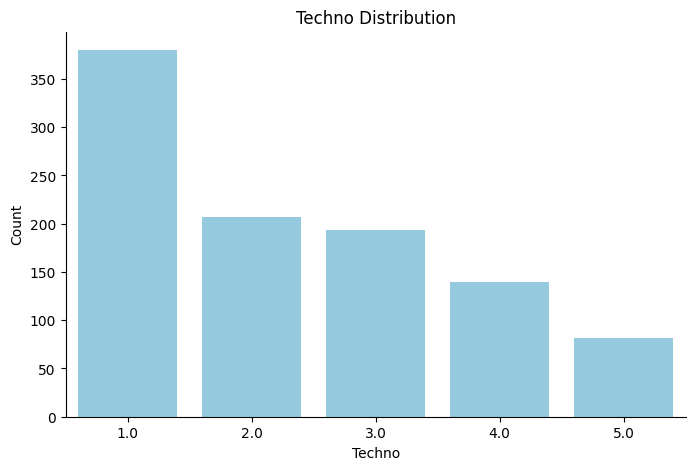

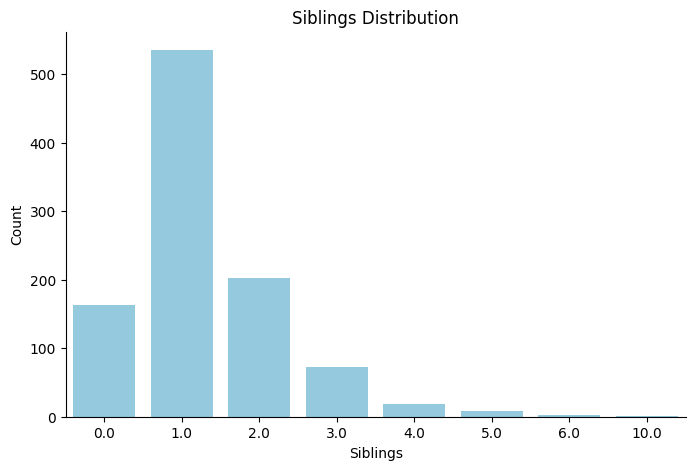

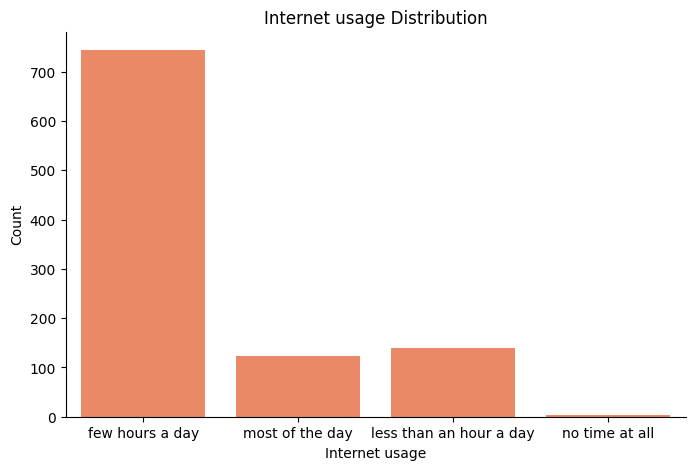

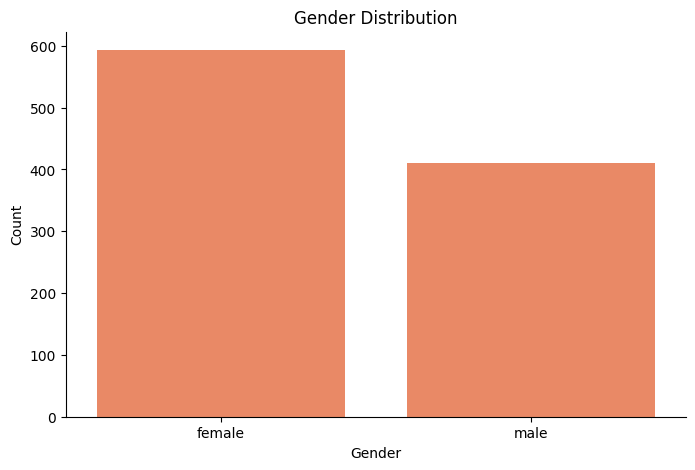

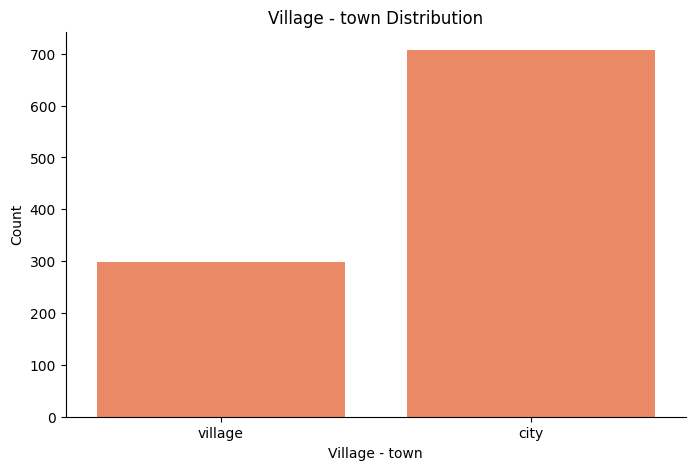

In [216]:
# 1. Univariate Analysis
# Numerical Histograms to show
for col in numeric:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df, color='skyblue')
    plt.title(f'{col} Distribution', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Count', fontsize=10)
    sns.despine()

# Categorical histograms to show frequency distribution
for col in categorical:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df, color='coral')
    plt.title(f'{col} Distribution', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Count', fontsize=10)
    sns.despine()

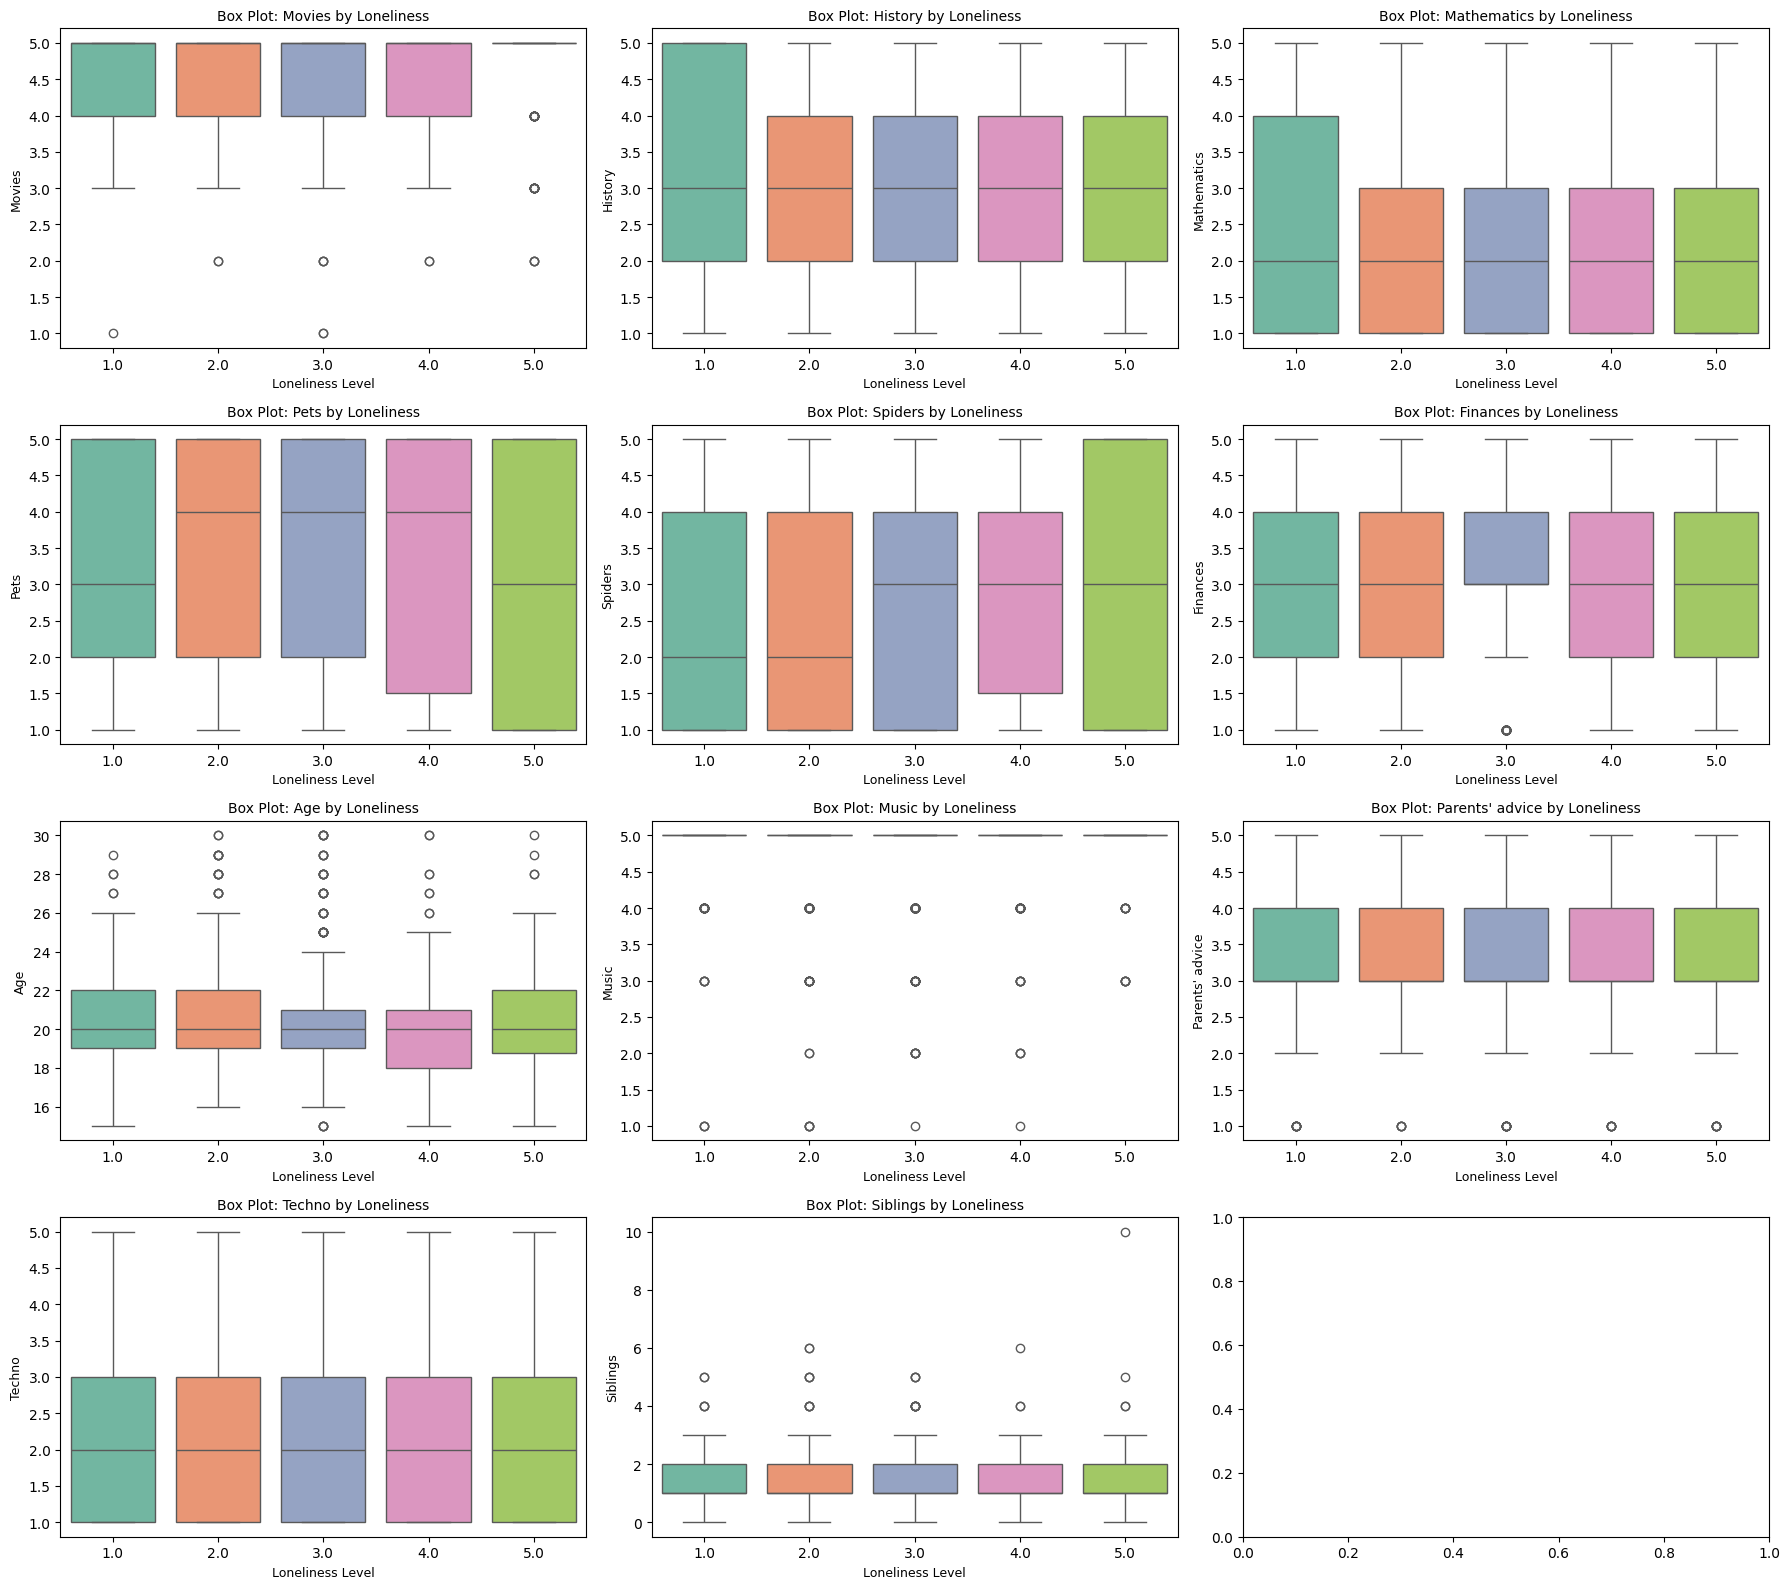

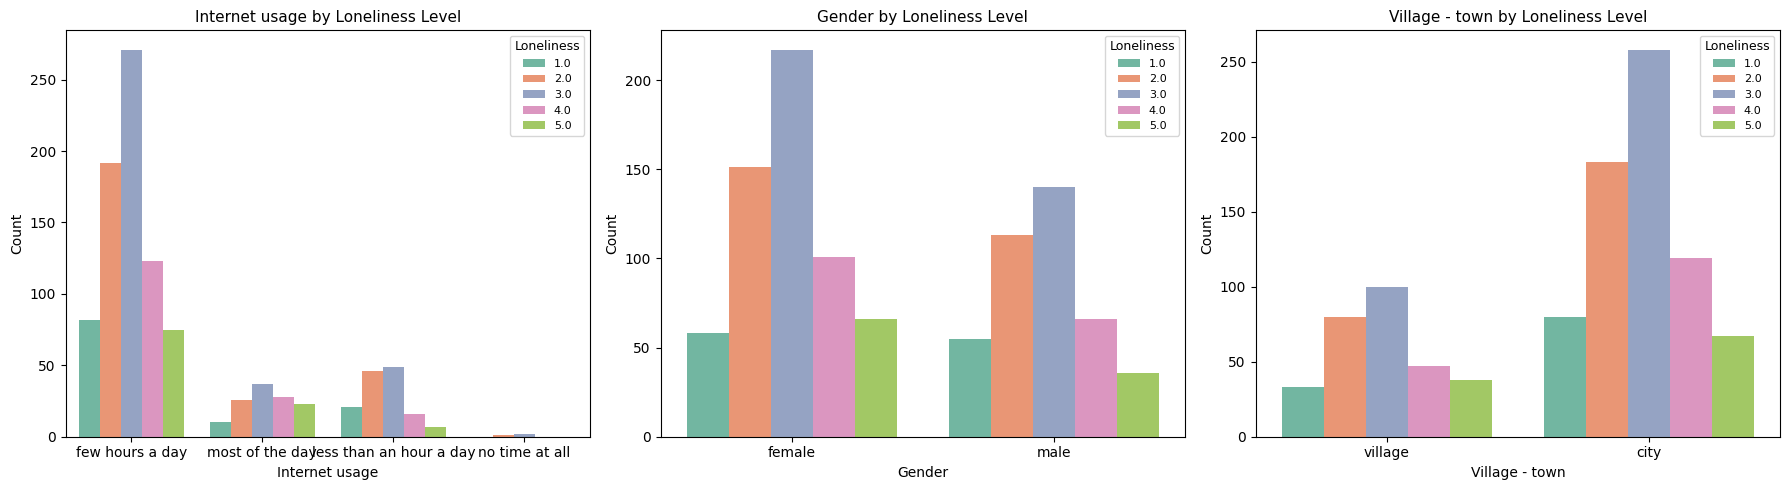

In [217]:
# 2. Multivariate Analysis
# Box Plots grouped by Loneliness Level
plot_cols = [col for col in numeric if col != 'Loneliness']
rows_of_figs = (len(plot_cols) + 2) // 3
fig, axes = plt.subplots(rows_of_figs, 3, figsize=(18, rows_of_figs * 4))
axes = axes.flatten()
for idx, col in enumerate(plot_cols):
    sns.boxplot(x='Loneliness', y=col, data=df, ax=axes[idx], hue='Loneliness', palette='Set2', legend=False)
    axes[idx].set_title(f'Box Plot: {col} by Loneliness', fontsize=10)
    axes[idx].set_xlabel('Loneliness Level', fontsize=9)
    axes[idx].set_ylabel(col, fontsize=9)
plt.tight_layout()

# Bar Charts: Frequency Distributions by Loneliness Level
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(categorical):
    sns.countplot(x=col, hue='Loneliness', data=df, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} by Loneliness Level', fontsize=11)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].legend(title='Loneliness', fontsize=8, title_fontsize=9)
plt.tight_layout()

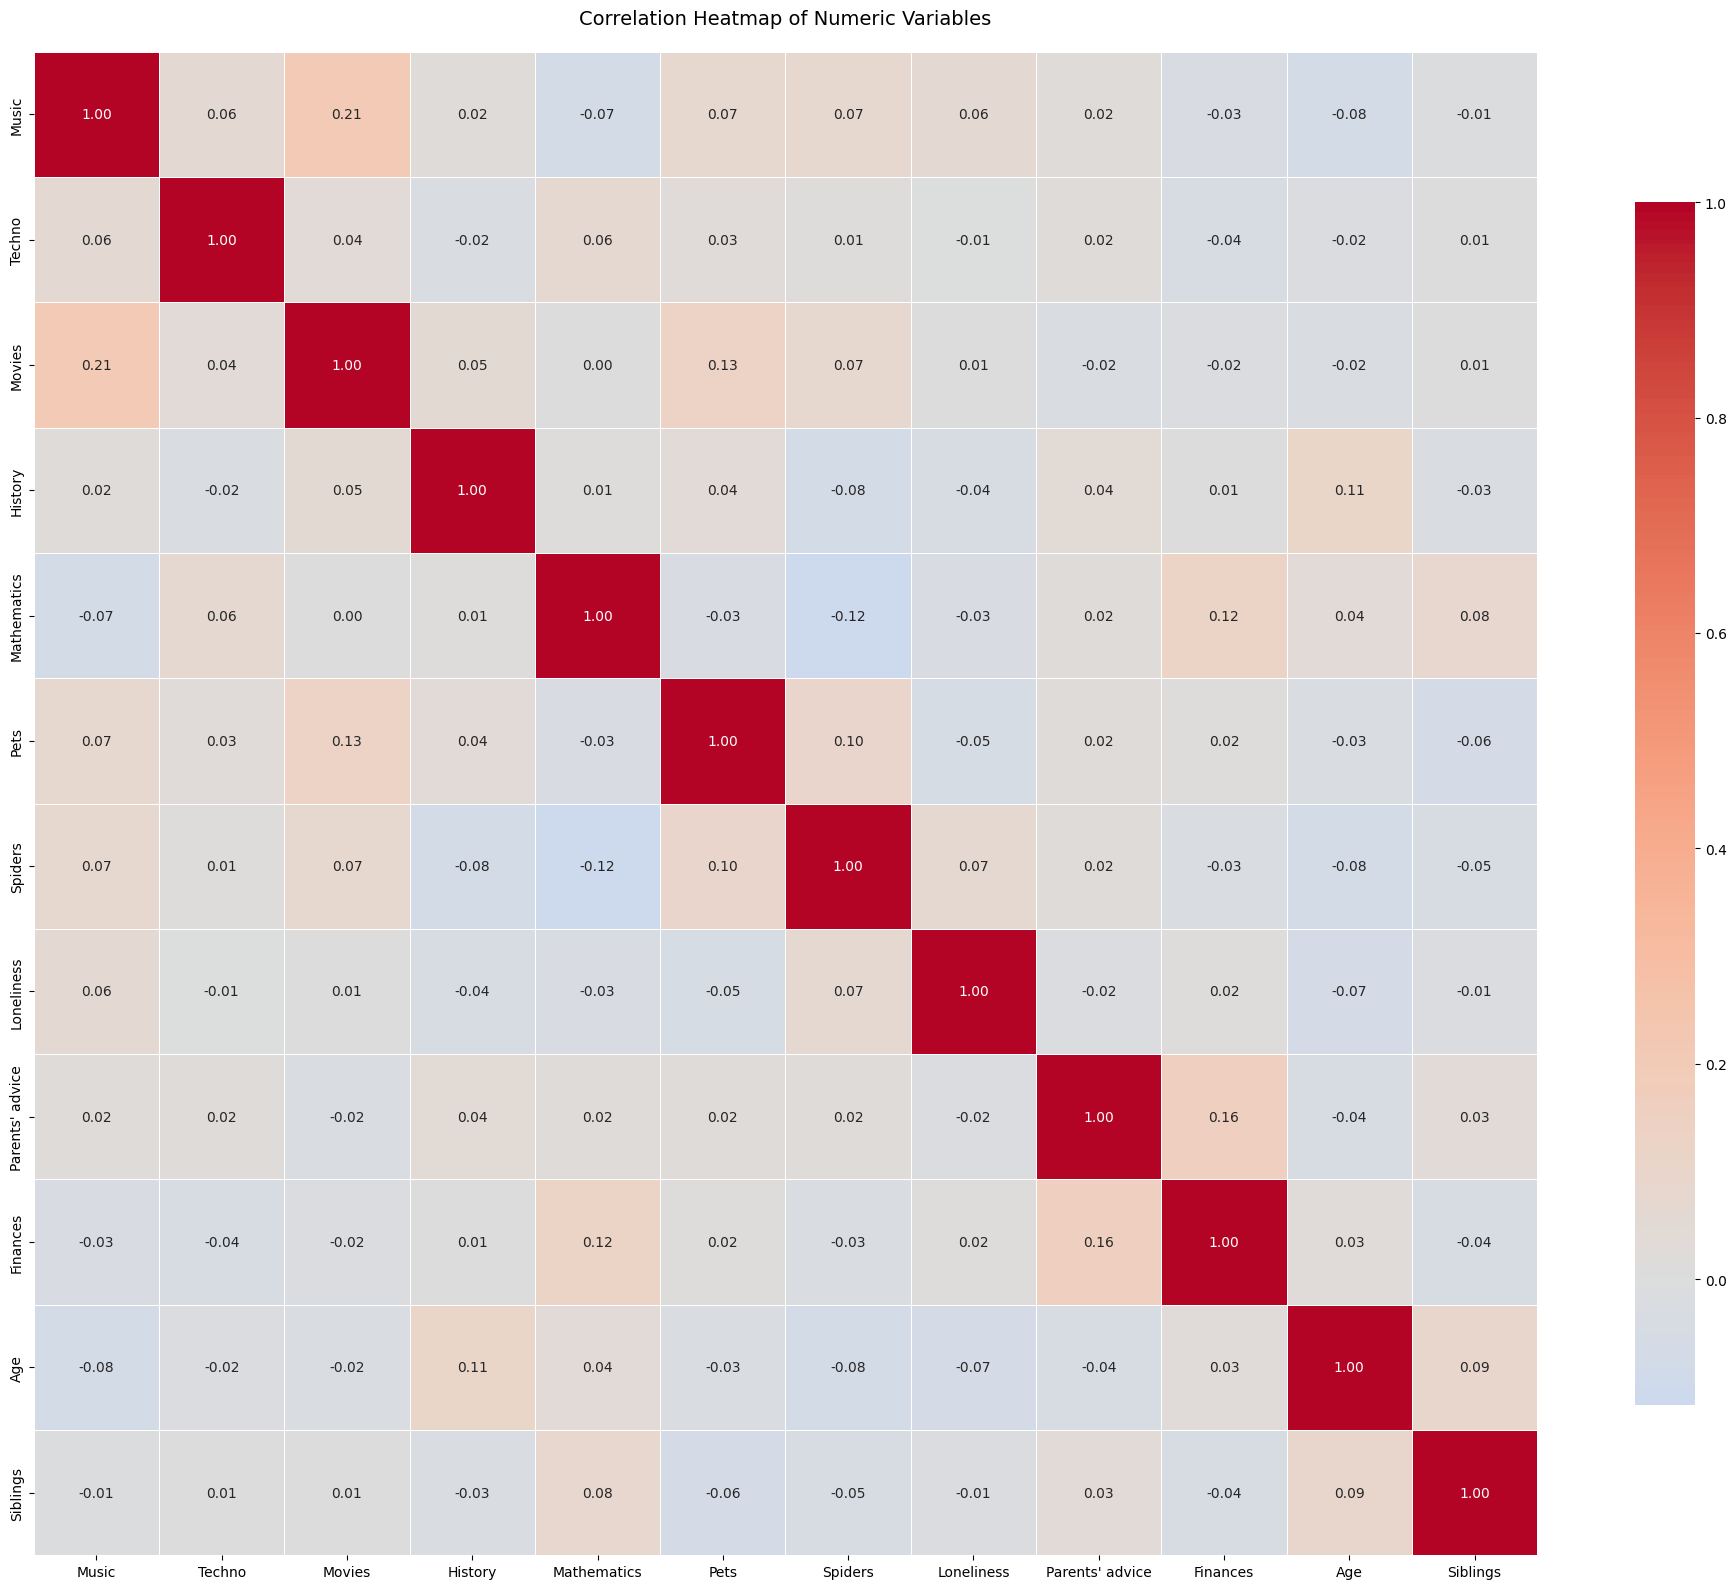

In [218]:
# 3. Correlation Analysis
# Correlation Heatmap
plt.figure(figsize=(20, 16))
numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14, pad=20)
plt.tight_layout()

## Part 3: Data Preprocessing

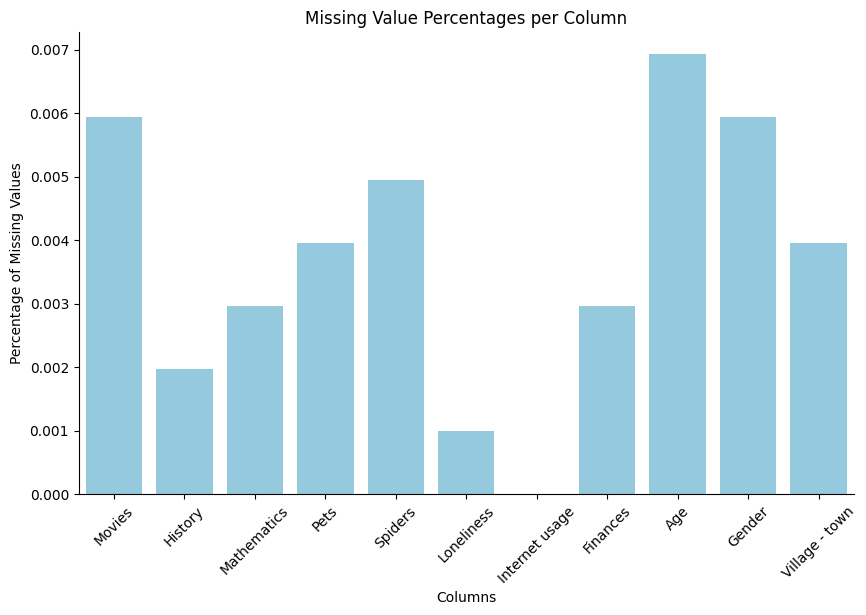

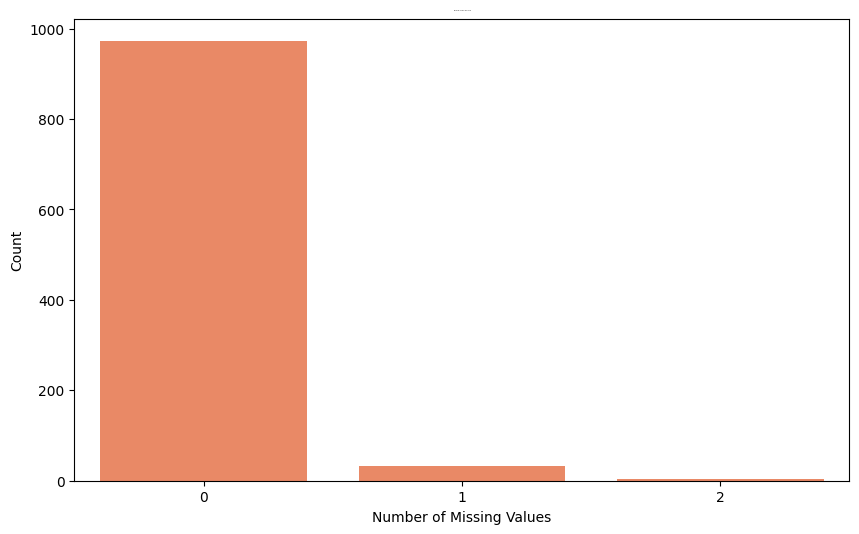

In [219]:
# 3.1 Feature Selection
# Variable Removal Documentation
df = df.drop(columns=['Music', "Parents' advice", 'Techno', 'Siblings'])

# 3.2 Handling Missing Values
# 1. Missing Data Analysis
# Visualization of missing value percentages per column
missing_percentages = df.isnull().mean()
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percentages.index, y=missing_percentages.values, color='skyblue')
plt.title('Missing Value Percentages per Column', fontsize=12)
plt.xlabel('Columns', fontsize=10)
plt.ylabel('Percentage of Missing Values', fontsize=10)
plt.xticks(rotation=45)
sns.despine()

# Summary of missing values per row
missing_rows = df.isnull().sum(axis=1)
plt.figure(figsize=(10, 6))
sns.countplot(x=missing_rows, color='coral')
plt.title('Missing Values per Row', fontsize=1)
plt.xlabel('Number of Missing Values', fontsize=10)
plt.ylabel('Count', fontsize=10)
# Capture original shape
original_shape = df.shape
# There are no columns with >10% missing value.
# Remove the rows with >10% missing values
df = df.dropna(thresh=df.shape[1] * 0.9, axis=0)

In [220]:
# 2. Removal Documentation
# Give the number of columns removed (>10% missing)
cols_removed = (missing_percentages > 0.1).sum()
print(f"Columns removed (>10% missing): {cols_removed}")
# Give the number of rows removed (>10% missing)
rows_removed = original_shape[0] - df.shape[0]
print(f"Rows removed (>10% missing): {rows_removed}")
# Before/after dataset dimensions
print(f"Original shape: {original_shape}")
print(f"New shape: {df.shape}")

Columns removed (>10% missing): 0
Rows removed (>10% missing): 4
Original shape: (1010, 11)
New shape: (1006, 11)


In [221]:
# 3. Imputation Results
# Before/after comparison of missing values
print("Before imputation:")
print(df.isnull().sum())

numeric = ['Movies', 'History', 'Mathematics', 'Pets', 'Spiders', 'Loneliness', 'Finances', 'Age']
categorical = ['Internet usage', 'Gender', 'Village - town']

for col in categorical:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numeric:
    df[col] = df[col].fillna(df[col].mean().round())

print("\nAfter numerical imputation:")
print(df.isnull().sum())

Before imputation:
Movies            5
History           1
Mathematics       2
Pets              3
Spiders           4
Loneliness        1
Internet usage    0
Finances          2
Age               6
Gender            5
Village - town    4
dtype: int64

After numerical imputation:
Movies            0
History           0
Mathematics       0
Pets              0
Spiders           0
Loneliness        0
Internet usage    0
Finances          0
Age               0
Gender            0
Village - town    0
dtype: int64


In [222]:
# 3.3 Encoding Categorical Variables
# 1. Categorical Variable Identification
print(f"The categorical variables are: {categorical}")
for col in categorical:
    print(f"The unique values in {col} are: {df[col].unique()}")
print("\n")

# Encode the variables
internet_map = {'no time at all': 0, 'less than an hour a day': 1, 'few hours a day': 2, 'most of the day': 3}
df['Internet usage'] = df['Internet usage'].map(internet_map)
df = pd.get_dummies(df, columns=['Gender', 'Village - town'], drop_first=True)
df = df.rename(columns={'Village - town_village': 'Village_not_town'})

# 2. Encoding Strategy Table
strategy = {
    'Variable': ['Internet usage', 'Gender', 'Village - town'],
    'Strategy': ['Ordinal Encoding', 'One-Hot Encoding (drop_first)', 'One-Hot Encoding (drop_first)'],
    'Justification': ['Preserve order (time spent)', 'Binary nominal', 'Binary nominal']
}
display(pd.DataFrame(strategy))

# 3. Encoding Results
#    Feature count before and after encoding, and Example of transformed variable (small sample)
print("\n")
print(f"Original feature count: {len(categorical) + len(numeric)}")
print(f"Current feature count: {df.shape[1]}")
print("\n")

display(df.head())

The categorical variables are: ['Internet usage', 'Gender', 'Village - town']
The unique values in Internet usage are: ['few hours a day' 'most of the day' 'less than an hour a day'
 'no time at all']
The unique values in Gender are: ['female' 'male']
The unique values in Village - town are: ['village' 'city']




,Variable,Strategy,Justification
0,Internet usage,Ordinal Encoding,Preserve order (time spent)
1,Gender,One-Hot Encoding (drop_first),Binary nominal
2,Village - town,One-Hot Encoding (drop_first),Binary nominal




Original feature count: 11
Current feature count: 11




,Movies,History,Mathematics,Pets,Spiders,Loneliness,Internet usage,Finances,Age,Gender_male,Village_not_town
0,5.0,1.0,3.0,4.0,1.0,3.0,2,3.0,20.0,False,True
1,5.0,1.0,5.0,5.0,1.0,2.0,2,3.0,19.0,False,False
2,5.0,1.0,5.0,5.0,1.0,5.0,2,2.0,20.0,False,False
3,5.0,4.0,4.0,1.0,5.0,5.0,3,2.0,22.0,False,False
4,5.0,3.0,2.0,1.0,1.0,3.0,2,4.0,20.0,False,True


## Part 4: Cross Validation (Train-Test Split)

The chosen ratio of training to testing data from this dataset is 80/20.



,Dataset,Samples,Features,% of Total
0,Training,804,11,79.920477
1,Testing,202,11,20.079523


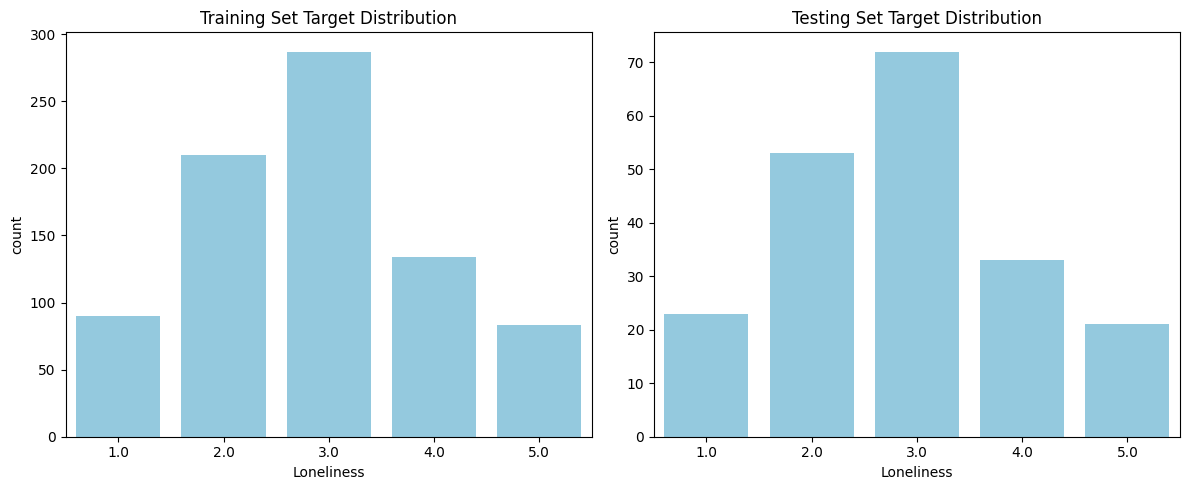

In [223]:
# 1. Split Strategy
# State train-test ratio and random_state value
train_ratio = 0.8
random_state = 42
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, train_size=train_ratio, random_state=random_state, stratify=df['Loneliness'])
print("The chosen ratio of training to testing data from this dataset is 80/20.\n")

# 2. Dataset Dimensions Table
summary_data = {
    'Dataset': ['Training', 'Testing'],
    'Samples': [train_df.shape[0], test_df.shape[0]],
    'Features': [train_df.shape[1], test_df.shape[1]],
    '% of Total': [len(train_df)/len(df)*100, len(test_df)/len(df)*100]
}
display(pd.DataFrame(summary_data))
print("\n")

# 3. Target Distribution Analysis
# Side-by-side visualizations of target distribution in train vs. test sets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Loneliness', data=train_df, ax=axes[0], color='skyblue')
axes[0].set_title('Training Set Target Distribution')
sns.countplot(x='Loneliness', data=test_df, ax=axes[1], color='skyblue')
axes[1].set_title('Testing Set Target Distribution')
plt.tight_layout()
plt.show()

## Part 5: Feature Scaling

Training data before scaling:


,Movies,History,Mathematics,Pets,Spiders,Loneliness,Internet usage,Finances,Age
count,804.00,804.00,804.00,804.00,804.00,804.00,804.00,804.00,804.00
mean,4.62,3.18,2.29,3.36,2.86,2.89,1.98,3.02,20.35
std,0.70,1.25,1.32,1.54,1.54,1.13,0.52,1.14,2.77
min,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,15.00
25%,4.00,2.00,1.00,2.00,1.00,2.00,2.00,2.00,19.00
50%,5.00,3.00,2.00,4.00,3.00,3.00,2.00,3.00,20.00
75%,5.00,4.00,3.00,5.00,4.00,4.00,2.00,4.00,21.00
max,5.00,5.00,5.00,5.00,5.00,5.00,3.00,5.00,30.00




Testing data before scaling:


,Movies,History,Mathematics,Pets,Spiders,Loneliness,Internet usage,Finances,Age
count,202.00,202.00,202.00,202.00,202.00,202.00,202.00,202.00,202.00
mean,4.61,3.31,2.52,3.24,2.69,2.88,1.98,3.04,20.73
std,0.65,1.31,1.45,1.57,1.53,1.14,0.54,1.15,3.00
min,2.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,15.00
25%,4.00,2.00,1.00,2.00,1.00,2.00,2.00,2.00,19.00
50%,5.00,3.00,2.00,3.00,2.00,3.00,2.00,3.00,20.00
75%,5.00,4.00,4.00,5.00,4.00,4.00,2.00,4.00,22.00
max,5.00,5.00,5.00,5.00,5.00,5.00,3.00,5.00,30.00




Scaling Strategy:


...



Training data after scaling:


,Movies,History,Mathematics,Pets,Spiders,Loneliness,Internet usage,Finances,Age,Gender_male,Village_not_town
count,804.00,804.00,804.00,804.00,804.00,804.00,804.00,804.00,804.00,804.00,804.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,2.89,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.13,1.00,1.00,1.00,1.00,1.00
min,-5.18,-1.74,-0.97,-1.54,-1.21,1.00,-3.83,-1.77,-1.93,-0.83,-0.65
25%,-0.89,-0.94,-0.97,-0.89,-1.21,2.00,0.04,-0.89,-0.49,-0.83,-0.65
50%,0.55,-0.14,-0.22,0.42,0.09,3.00,0.04,-0.02,-0.13,-0.83,-0.65
75%,0.55,0.66,0.54,1.07,0.74,4.00,0.04,0.86,0.24,1.21,1.54
max,0.55,1.46,2.05,1.07,1.39,5.00,1.98,1.73,3.49,1.21,1.54




Testing data after scaling:


,Movies,History,Mathematics,Pets,Spiders,Loneliness,Internet usage,Finances,Age,Gender_male,Village_not_town
count,202.00,202.00,202.00,202.00,202.00,202.00,202.00,202.00,202.00,202.00,202.00
mean,-0.01,0.10,0.18,-0.08,-0.11,2.88,0.00,0.02,0.14,0.01,-0.01
std,0.94,1.05,1.09,1.02,0.99,1.14,1.04,1.00,1.08,1.00,1.00
min,-3.75,-1.74,-0.97,-1.54,-1.21,1.00,-3.83,-1.77,-1.93,-0.83,-0.65
25%,-0.89,-0.94,-0.97,-0.89,-1.21,2.00,0.04,-0.89,-0.49,-0.83,-0.65
50%,0.55,-0.14,-0.22,-0.23,-0.56,3.00,0.04,-0.02,-0.13,-0.83,-0.65
75%,0.55,0.66,1.29,1.07,0.74,4.00,0.04,0.86,0.60,1.21,1.54
max,0.55,1.46,2.05,1.07,1.39,5.00,1.98,1.73,3.49,1.21,1.54




Visual Comparison:


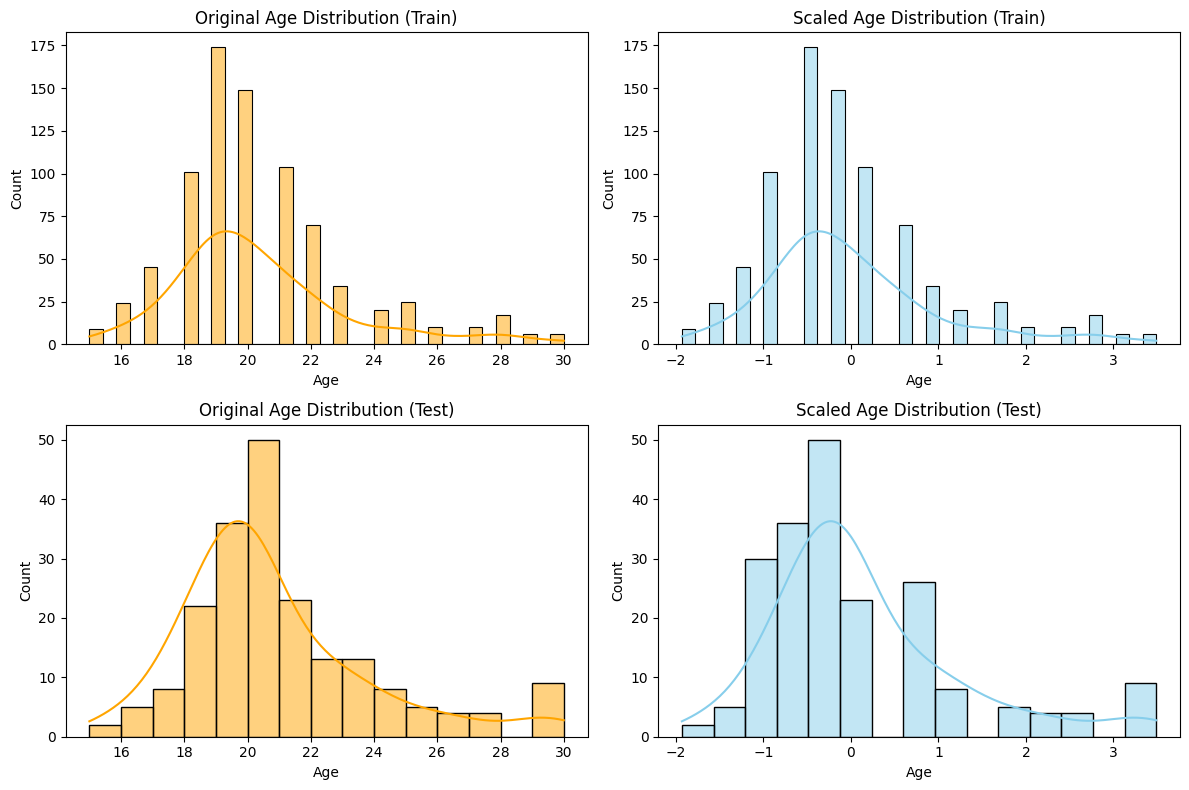

In [224]:
# 1. Scaling Decision Table
print("Training data before scaling:")
display(train_df.describe().round(2))
print("\n")

print("Testing data before scaling:")
display(test_df.describe().round(2))
print("\n")

print("Scaling Strategy:")
scaling_strategy = {
    'Variable Group': ['Age', 'Likert Features (1-5)', 'Internet Usage (Ordinal)', 'Binary Variables'],
    'Original Range': ['15-30', '1-5', '0-3', '0-1'],
    'Strategy': ['StandardScaler', 'StandardScaler', 'StandardScaler', 'StandardScaler'],
    'Justification': ['Standardize to Mean=0, Std=1', 'Standardize to Mean=0, Std=1', 'Standardize to Mean=0, Std=1', 'Standardize to Mean=0, Std=1']
}
display(pd.DataFrame(scaling_strategy))
print("\n")

# 2. Scaling Methodology
# This code is where the scaling happens. It proves that I fit on the training
# data only.
from sklearn.preprocessing import StandardScaler
train_df_unscaled = train_df.copy()
test_df_unscaled = test_df.copy()

features = [col for col in train_df.columns if col != 'Loneliness']
scaler = StandardScaler()
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

# 3. Scaling Verification
print("Training data after scaling (mean ≈ 0, std ≈ 1):")
display(train_df.describe().round(2))
print("\n")

print("Testing data after scaling (mean ≈ 0, std ≈ 1):")
display(test_df.describe().round(2))
print("\n")

# 4. Visual Comparison
print("Visual Comparison:")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(train_df_unscaled['Age'], kde=True, ax=axes[0, 0], color='orange')
axes[0, 0].set_title('Original Age Distribution (Train)')
sns.histplot(train_df['Age'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Scaled Age Distribution (Train)')
sns.histplot(test_df_unscaled['Age'], kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Original Age Distribution (Test)')
sns.histplot(test_df['Age'], kde=True, ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('Scaled Age Distribution (Test)')
plt.tight_layout()
plt.show()